In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

L = 100 #number of lattice points in each dimension
size = L*L #total number of lattice points
J = 1  #Coupling Coefficient
T = .1 #Temperature
N = 100 #number of monte-carlo steps

#Data Collection
M_t = np.zeros(N) #magnetization
E_t = np.zeros(N) #energy per spin/lattice point
s_t = []

#Begin in Random Initial State
state = np.random.choice([-1,1],(L,L))

#Begin Iteration of MCS (monte-carlo steps)
for n_out in range(N):
    #store state
    s_t.append(state[:,:])
    #compute and store magnetization
    M_t[n_out] = np.sum(state)/size
    #compute and store energy per spin
    E_t[n_out] = -J*np.sum(state*(np.roll(state,1,0)+np.roll(state,1,1)))/size
    #For each MCS, attempt flipping one spin for every lattice point
    for n_in in range(size):
        #choose a random lattice point
        xpos = np.random.randint(0,L)
        xp = xpos+1
        if xp == L:
            xp = 0
        xm = xpos-1
        ypos = np.random.randint(0,L)
        yp = ypos+1
        if yp == L:
            yp = 0
        ym = ypos-1
        #calculate change in energy of prospective flip
        dU = 2*J*state[xpos,ypos]*(state[xm,ym] + state[xm,yp] + state[xp,ym] + state[xp,yp])
        #decide whether to flip
        if dU <= 0:
            state[xpos,ypos] *= -1
        elif np.random.rand() < np.exp(-dU/T):
            state[xpos,ypos] *= -1

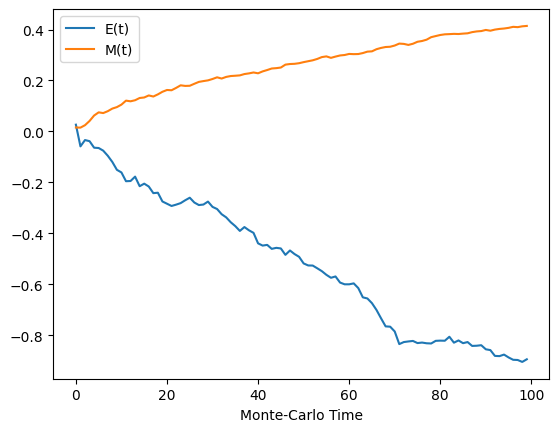

In [2]:
start=0
end=20000
plt.plot(E_t[start:end], label='E(t)')
plt.plot(M_t[start:end], label='M(t)')
plt.legend()
plt.xlabel("Monte-Carlo Time")
plt.show()

In [3]:
E_av = np.sum(E_t)/N
E_av

np.float64(-0.514768)

In [4]:
M_av = np.sum(M_t)/N
M_av

np.float64(0.258506)

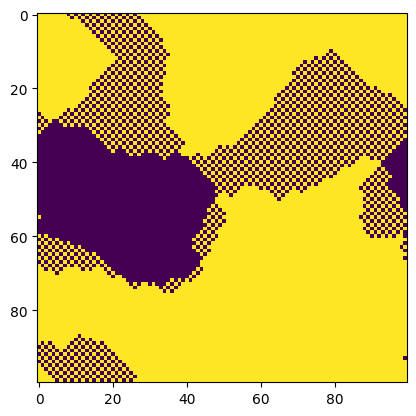

In [11]:
plt.imshow(s_t[1])
plt.show()